In [1]:
%matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML, display
import base64

In [4]:
import gymnasium as gym
import jax
import jax.numpy as jnp

from jax_mc_pilco.simulators.collect_data import collect_experience
from jax_mc_pilco.training.learning import actor_critic_training_loop, world_training_loop

ImportError: cannot import name 'StaticCritic' from 'jax_mc_pilco.policy_learning.critic' (/home/dmarthaler/dev/jax-mc-pilco/src/jax_mc_pilco/policy_learning/critic.py)

In [5]:
jax.config.update("jax_enable_x64", True)

In [6]:
problem: str = "InvertedPendulum-v5"
env = gym.make(problem)

key = jax.random.key(seed=4)
key, subkey = jax.random.split(key)
_, max_episode_len, states, actions, next_states, rewards = collect_experience(env, 5_000, subkey, None)
print(f"Environment data collection complete. Sampled {states.shape[0]} points.")

Environment data collection complete. Sampled 5001 points.


In [7]:
key, subkey = jax.random.split(key)
dynamics, d_losses = world_training_loop(subkey, states, actions)

print("Dynamics model fit complete. Final validation loss:", d_losses["val"][-1])

 26%|███████████████████▏                                                       | 255/1000 [01:12<03:31,  3.53it/s, train=-3.85, val=-3.85 (Max patience reached)]

Dynamics model fit complete. Final validation loss: -3.8484348159774164


In [17]:
key, subkey = jax.random.split(key)
actor, ac_losses = actor_critic_training_loop(
    subkey,
    states,
    actions,
    jnp.min(actions, axis=0),
    jnp.max(actions, axis=0),
    dynamics,
    actor_model = actor,
    max_epochs=5000,
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:02<00:00, 79.37it/s]


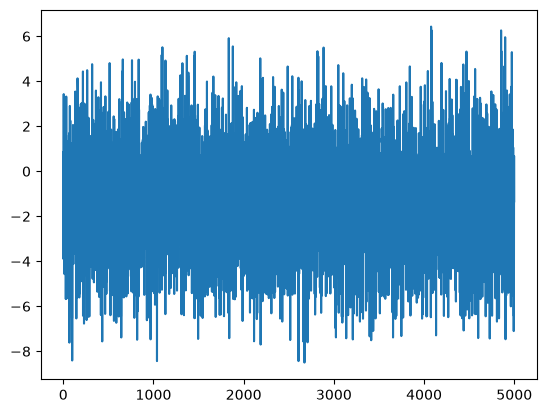

In [18]:
import matplotlib.pyplot as plt
plt.plot(ac_losses['act'])

In [22]:
# Now we want to use this action in the real environment

In [10]:
env.close()

In [11]:
# Create the environment with rgb_array render mode
env = gym.make(problem, render_mode="rgb_array")

# Wrap the environment to record video into a 'video' directory
env = RecordVideo(env, video_folder="video", episode_trigger=lambda e: True)

observation, info = env.reset()
terminated = False
truncated = False

hidden = jnp.zeros((dynamics.memory.hidden_size,))

while not terminated and not truncated:
#for _ in range(25):
    combined_latent = jnp.concatenate([observation, hidden], axis=-1)
    key, act_key = jax.random.split(key)
    action  = actor.sample_action(act_key, context=combined_latent)
    new_observation, reward, terminated, truncated, info = env.step(action)
    hidden = hidden = dynamics.memory(jnp.concatenate([observation, action], axis=-1), hidden)
    observation = new_observation
env.close()

/home/dmarthaler/dev/jax-mc-pilco/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/dmarthaler/dev/jax-mc-pilco/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [12]:
def embed_video(path):
    video = open(path, "br").read()
    video_base64 = base64.b64encode(video).decode()
    display(HTML(f'''
        <video width="640" height="480" controls>
            <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
        </video>
    '''))

# Display the first recorded episode video
embed_video("video/rl-video-episode-0.mp4")